<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/resnet40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("divg07/casia-20-image-tampering-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.56G/2.56G [00:30<00:00, 91.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/divg07/casia-20-image-tampering-detection-dataset/versions/1


Using Colab cache for faster access to the 'casia-20-image-tampering-detection-dataset' dataset.
Loading training and validation datasets...
Found 9555 files belonging to 2 classes.
Using 7644 files for training.
Found 9555 files belonging to 2 classes.
Using 1911 files for validation.

🚀 Starting ResNet50 training for 5 epochs...
Epoch 1/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 64s 219ms/step - accuracy: 0.7835 - loss: 0.4871 - val_accuracy: 0.1732 - val_loss: 1.3845
Epoch 2/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - accuracy: 0.8019 - loss: 0.4088 - val_accuracy: 0.3804 - val_loss: 0.9756
Epoch 3/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.8201 - loss: 0.3806 - val_accuracy: 0.3731 - val_loss: 1.0288
Epoch 4/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.8289 - loss: 0.3652 - val_accuracy: 0.3919 - val_loss: 0.9177
Epoch 5/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - accuracy: 0.8357 - loss: 0.3460 - val_accuracy: 0.4192 - val_loss: 1.0381

✅ Training compl

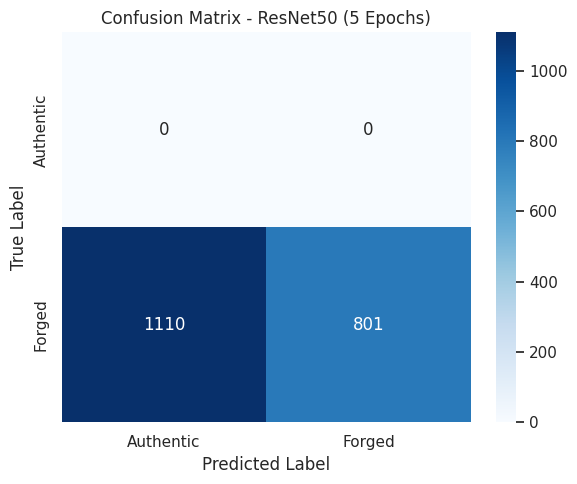

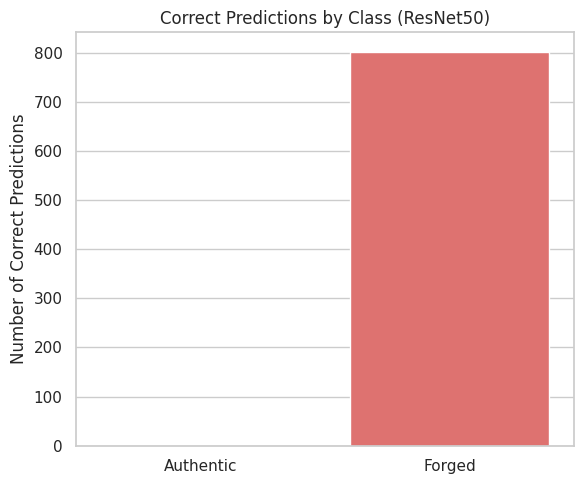

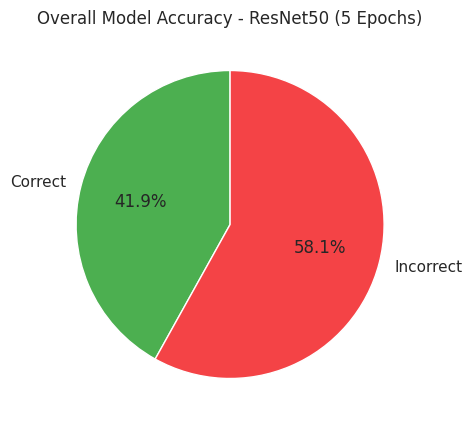

 ✅ ALL CHARTS GENERATED AND SAVED TO COLAB FILES


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os # Import os module for path manipulation
import kagglehub # Added to ensure kagglehub is available if path is defined here

# 1. ARCHITECTURE: Advanced ResNet50 (Transfer Learning)
def build_resnet(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)

    # Load pre-trained base
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
    base_model.trainable = False # Freeze core brain

    # Custom classification layers
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name="ResNet50_Colab")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def run_colab_pipeline(dataset_path):
    # 2. Setup Parameters (5 Epochs)
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 5
    WEIGHTS_FILE = "ResNet50_epoch_5.weights.h5"
    VALIDATION_SPLIT = 0.2 # 20% of data for validation
    SEED = 42 # for reproducible split

    print("Loading training and validation datasets...")

    # The actual class folders ('Au' and 'Tp') are under 'CASIA2'.
    # We need to point image_dataset_from_directory to the parent 'CASIA2' folder.
    DATASET_TOP_LEVEL_FOLDER = "CASIA2"
    base_data_dir = os.path.join(dataset_path, DATASET_TOP_LEVEL_FOLDER)

    # 3. Load Data
    # Use validation_split and subset arguments to create train and validation datasets
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        base_data_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        validation_split=VALIDATION_SPLIT,
        subset='training',
        seed=SEED,
        class_names=['Au', 'Tp'] # Explicitly specify class names
    )
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        base_data_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        validation_split=VALIDATION_SPLIT,
        subset='validation',
        seed=SEED,
        shuffle=False, # No need to shuffle validation data
        class_names=['Au', 'Tp'] # Explicitly specify class names
    )

    # Check and print class distribution in val_ds
    val_labels = []
    for _, labels in val_ds:
        val_labels.extend(labels.numpy().flatten())
    val_labels = np.array(val_labels)
    unique_val_labels, val_label_counts = np.unique(val_labels, return_counts=True)
    print(f"Validation set label distribution: {dict(zip(unique_val_labels, val_label_counts))}")

    # 4. Build Model
    model = build_resnet()

    print(f"\n🚀 Starting ResNet50 training for {EPOCHS} epochs...")

    # 5. Train the Model
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    # 6. Save the Weights
    model.save_weights(WEIGHTS_FILE)
    print(f"\n✅ Training complete! Weights saved as '{WEIGHTS_FILE}'")

    # =========================================================================
    # 7. EVALUATION & VISUALIZATION PHASE
    # =========================================================================
    print("\n📊 Generating Evaluation Metrics...")

    y_true = []
    y_pred_probs = []

    # Use the validation set that is already loaded in memory
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_pred_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > 0.5).astype(int)

    sns.set_theme(style="whitegrid") # Colab looks better with Seaborn themes

    # --- Chart 1: Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Authentic', 'Forged'], yticklabels=['Authentic', 'Forged'])
    plt.title('Confusion Matrix - ResNet50 (5 Epochs)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix_resnet_5.png')
    plt.show() # Displays inline in Colab

    # --- Chart 2: Bar Chart ---
    plt.figure(figsize=(6,5))
    categories = ['Authentic', 'Forged']
    correct = [cm[0,0], cm[1,1]]
    sns.barplot(x=categories, y=correct, hue=categories, palette='magma', legend=False)
    plt.title('Correct Predictions by Class (ResNet50)')
    plt.ylabel('Number of Correct Predictions')
    plt.tight_layout()
    plt.savefig('performance_barchart_resnet_5.png')
    plt.show()

    # --- Chart 3: Pie Chart ---
    plt.figure(figsize=(6,5))
    total_correct = np.sum(np.diag(cm))
    total_incorrect = len(y_true) - total_correct
    plt.pie([total_correct, total_incorrect], labels=['Correct', 'Incorrect'], autopct='%1.1f%%', colors=['#4CAF50', '#F44346'], startangle=90)
    plt.title('Overall Model Accuracy - ResNet50 (5 Epochs)')
    plt.savefig('prediction_piechart_resnet_5.png')
    plt.show()

    print("==================================================")
    print(" ✅ ALL CHARTS GENERATED AND SAVED TO COLAB FILES")
    print("==================================================")

    return y_true, y_pred

# 8. Execute the Pipeline
if __name__ == "__main__":
    # Ensure 'path' is defined in this cell if it wasn't carried over from a previous cell.
    # kagglehub.dataset_download is designed to cache, so it won't re-download if already done.
    path = kagglehub.dataset_download("divg07/casia-20-image-tampering-detection-dataset")
    y_true_global, y_pred_global = run_colab_pipeline(path) # Pass the 'path' variable and capture return values

In [17]:
from sklearn.metrics import *

print("===============VISUALIZRION===============")

print(f"Accuracy: {accuracy_score(y_true_global, y_pred_global)}")
print("Confusion Matrix:")
print(confusion_matrix(y_true_global, y_pred_global))
print("Classification Report:")
print(classification_report(y_true_global, y_pred_global))
print(f"ROC AUC Score: {roc_auc_score(y_true_global, y_pred_global)}")
# roc_curve returns fpr, tpr, thresholds - it's better to plot this
# print(roc_curve(y_true_global, y_pred_global))
# precision_recall_curve returns precision, recall, thresholds - better to plot
# print(precision_recall_curve(y_true_global, y_pred_global))
print(f"Precision: {precision_score(y_true_global, y_pred_global)}")
print(f"Recall: {recall_score(y_true_global, y_pred_global)}")
print(f"F1 Score: {f1_score(y_true_global, y_pred_global)}")

===============VISUALIZRION===============
Accuracy: 0.41915227629513346
Confusion Matrix:
[[   0    0]
 [1110  801]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.42      0.59      1911

    accuracy                           0.42      1911
   macro avg       0.50      0.21      0.30      1911
weighted avg       1.00      0.42      0.59      1911

ROC AUC Score: nan
Precision: 1.0
Recall: 0.41915227629513346
F1 Score: 0.5907079646017699


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: 